# Specific Stock Minima / Maxima Simulation


In [19]:
import matplotlib.pyplot as plt
import pandas as pd

import analysis_interfaces.interface_specific_stock as iss
import analysis_types.simulation as sim


## Block 1: Parameters


In [20]:
ticker = "NVDA"
initial_funds = 100
include_fundamentals = True
include_sentiment = False  # True requires API keys and adds latency

period = "5d"  # Valid periods: 1d,5d,1mo,3mo,6mo,1y,2y,5y,10y,ytd,max
no_change_threshold = 0.02  # Less than 2% is treated as a stationary plane.
trade_fraction = 0.10  # Buy or sell 10% of the current cash/position at each turning point.


## Block 4: Simulate Local Minima / Maxima Strategy


In [21]:
df_pred = iss.build_prediction_and_stats(
    ticker,
    include_sentiment=include_sentiment,
    period=period,
)


In [22]:
def price_direction(reference_price, comparison_price, no_change_threshold):
    if pd.isna(reference_price) or pd.isna(comparison_price) or comparison_price == 0:
        return None

    pct_change = (reference_price - comparison_price) / comparison_price
    if abs(pct_change) < no_change_threshold:
        return 0
    return 1 if pct_change > 0 else -1


def classify_price_point(prev_close, current_close, next_close, no_change_threshold):
    if pd.isna(prev_close) or pd.isna(current_close) or pd.isna(next_close):
        return "EDGE"

    direction_from_prev = price_direction(current_close, prev_close, no_change_threshold)
    direction_to_next = price_direction(next_close, current_close, no_change_threshold)

    if direction_from_prev == 0 or direction_to_next == 0:
        return "STATIONARY"
    if direction_from_prev == -1 and direction_to_next == 1:
        return "LOCAL_MINIMUM"
    if direction_from_prev == 1 and direction_to_next == -1:
        return "LOCAL_MAXIMUM"
    if direction_from_prev == 1 and direction_to_next == 1:
        return "RISING"
    if direction_from_prev == -1 and direction_to_next == -1:
        return "FALLING"
    return "HOLD"


def simulate_local_extrema_strategy(
    df_pred,
    initial_funds,
    no_change_threshold=0.02,
    trade_fraction=0.10,
):
    if no_change_threshold < 0:
        raise ValueError("no_change_threshold must be zero or positive")
    if not 0 < trade_fraction <= 1:
        raise ValueError("trade_fraction must be greater than 0 and at most 1")

    price_history = sim.get_price_history(df_pred).copy()
    if price_history.empty:
        raise ValueError("Price history is empty")

    starting_cash = float(initial_funds)
    if starting_cash < 0:
        raise ValueError("initial_funds must be zero or a positive number")

    price_history["prev_close"] = price_history["Close"].shift(1)
    price_history["next_close"] = price_history["Close"].shift(-1)
    price_history["price_change_from_prev_pct"] = (
        (price_history["Close"] - price_history["prev_close"])
        / price_history["prev_close"]
        * 100
    )
    price_history["price_change_to_next_pct"] = (
        (price_history["next_close"] - price_history["Close"])
        / price_history["Close"]
        * 100
    )
    price_history["signal_text"] = price_history.apply(
        lambda row: classify_price_point(
            row["prev_close"],
            row["Close"],
            row["next_close"],
            no_change_threshold,
        ),
        axis=1,
    )
    price_history["signal_number"] = price_history["signal_text"].map(
        {
            "LOCAL_MINIMUM": 1,
            "LOCAL_MAXIMUM": -1,
            "STATIONARY": 0,
            "RISING": 0,
            "FALLING": 0,
            "EDGE": 0,
            "HOLD": 0,
        }
    ).fillna(0)

    cash_balance = starting_cash
    units_held = 0.0
    total_cost = 0.0
    transactions = []
    daily_rows = []

    for _, row in price_history.iterrows():
        action = "HOLD"
        trade_units = 0.0
        trade_value = 0.0
        trade_price = row["Trade_Price"]

        if row["signal_text"] == "LOCAL_MINIMUM" and trade_price > 0 and cash_balance > 0:
            trade_value = cash_balance * trade_fraction
            trade_units = trade_value / trade_price
            cash_balance -= trade_value
            units_held += trade_units
            total_cost += trade_value
            action = "BUY"
        elif row["signal_text"] == "LOCAL_MAXIMUM" and trade_price > 0 and units_held > 0:
            trade_units = units_held * trade_fraction
            average_cost_per_unit = total_cost / units_held if units_held > 0 else 0.0
            trade_value = trade_units * trade_price
            cash_balance += trade_value
            units_held -= trade_units
            total_cost -= average_cost_per_unit * trade_units
            total_cost = max(total_cost, 0.0)
            units_held = max(units_held, 0.0)
            action = "SELL"

        holdings_value = units_held * row["Close"]
        portfolio_value = cash_balance + holdings_value
        average_cost_per_unit = total_cost / units_held if units_held > 0 else 0.0
        profit_loss = portfolio_value - starting_cash
        profit_loss_pct = (profit_loss / starting_cash * 100) if starting_cash else None

        daily_rows.append(
            {
                "Date": row["Date"],
                "Open": row["Open"],
                "Close": row["Close"],
                "Trade_Price": trade_price,
                "price_change_from_prev_pct": row["price_change_from_prev_pct"],
                "price_change_to_next_pct": row["price_change_to_next_pct"],
                "signal_text": row["signal_text"],
                "signal_number": row["signal_number"],
                "action": action,
                "trade_units": trade_units,
                "trade_value": trade_value,
                "cash_balance": cash_balance,
                "units_held": units_held,
                "average_cost_per_unit": average_cost_per_unit,
                "holdings_value": holdings_value,
                "portfolio_value": portfolio_value,
                "profit_loss": profit_loss,
                "profit_loss_pct": profit_loss_pct,
            }
        )

        if action in ("BUY", "SELL"):
            transactions.append(
                {
                    "Date": row["Date"],
                    "action": action,
                    "signal_text": row["signal_text"],
                    "trade_price": trade_price,
                    "units": trade_units,
                    "trade_value": trade_value,
                    "cash_balance": cash_balance,
                    "units_held": units_held,
                    "portfolio_value": portfolio_value,
                }
            )

    daily_history = pd.DataFrame(daily_rows)
    transactions_frame = pd.DataFrame(
        transactions,
        columns=[
            "Date",
            "action",
            "signal_text",
            "trade_price",
            "units",
            "trade_value",
            "cash_balance",
            "units_held",
            "portfolio_value",
        ],
    )
    latest_row = daily_history.iloc[-1]

    return {
        "price_history": price_history,
        "daily_history": daily_history,
        "transactions": transactions_frame,
        "summary": pd.DataFrame(
            [
                {
                    "start_date": daily_history.iloc[0]["Date"],
                    "end_date": latest_row["Date"],
                    "initial_funds": starting_cash,
                    "ending_cash_balance": latest_row["cash_balance"],
                    "units_held": latest_row["units_held"],
                    "average_cost_per_unit": latest_row["average_cost_per_unit"],
                    "latest_close": latest_row["Close"],
                    "holdings_value": latest_row["holdings_value"],
                    "total_portfolio_value": latest_row["portfolio_value"],
                    "profit_loss": latest_row["profit_loss"],
                    "profit_loss_pct": latest_row["profit_loss_pct"],
                    "buy_transactions": int((transactions_frame["action"] == "BUY").sum()) if not transactions_frame.empty else 0,
                    "sell_transactions": int((transactions_frame["action"] == "SELL").sum()) if not transactions_frame.empty else 0,
                }
            ]
        ),
    }


simulation_result = simulate_local_extrema_strategy(
    df_pred,
    initial_funds=initial_funds,
    no_change_threshold=no_change_threshold,
    trade_fraction=trade_fraction,
)


## Block 5: Portfolio Summary


In [23]:
df_pred


,Date,Open,High,Low,Close,Adj Close,Volume,TICKER,SMA10,SMA20,...,Daily Gain/Loss,technical_analysis_buy_score,technical_analysis_sell_score,fundamental_snapshot_report_date,fundamental_snapshot_available_from,fundamental_analysis_score,sentiment_analysis_score,multifactor_analysis_score,Signal,Signal_Text
0,2026-03-16,182.970001,188.869995,181.410004,183.220001,183.220001,215647512,NVDA,NaN,NaN,...,0.250000,0.10,-0.45,2025-10-31,2025-12-15,0.2,0.0,0.22125,0.025513,HOLD
1,2026-03-13,184.919998,186.089996,179.940002,180.250000,180.250000,160513800,NVDA,NaN,NaN,...,-4.669998,0.10,-0.45,2025-10-31,2025-12-15,0.2,0.0,0.22125,0.025513,HOLD
2,2026-03-12,184.050003,184.940002,181.750000,183.139999,183.139999,155762700,NVDA,NaN,NaN,...,-0.910004,0.10,-0.45,2025-10-31,2025-12-15,0.2,0.0,0.22625,0.027163,HOLD
3,2026-03-11,185.910004,187.619995,184.449997,186.029999,186.029999,145280400,NVDA,NaN,NaN,...,0.119995,0.35,-0.20,2025-10-31,2025-12-15,0.2,0.0,0.22875,0.192988,WEAK BUY
4,2026-03-10,182.399994,186.440002,182.009995,184.770004,184.760010,179118500,NVDA,NaN,NaN,...,2.370010,0.00,-0.10,2025-10-31,2025-12-15,0.2,0.0,0.22875,0.110488,WEAK BUY


In [24]:
simulation_result["transactions"]


,Date,action,signal_text,trade_price,units,trade_value,cash_balance,units_held,portfolio_value


In [25]:
simulation_result["summary"]


,start_date,end_date,initial_funds,ending_cash_balance,units_held,average_cost_per_unit,latest_close,holdings_value,total_portfolio_value,profit_loss,profit_loss_pct,buy_transactions,sell_transactions
0,2026-03-10,2026-03-16,100.0,100.0,0.0,0.0,183.220001,0.0,100.0,0.0,0.0,0,0


## Block 6: Price and Portfolio Plot


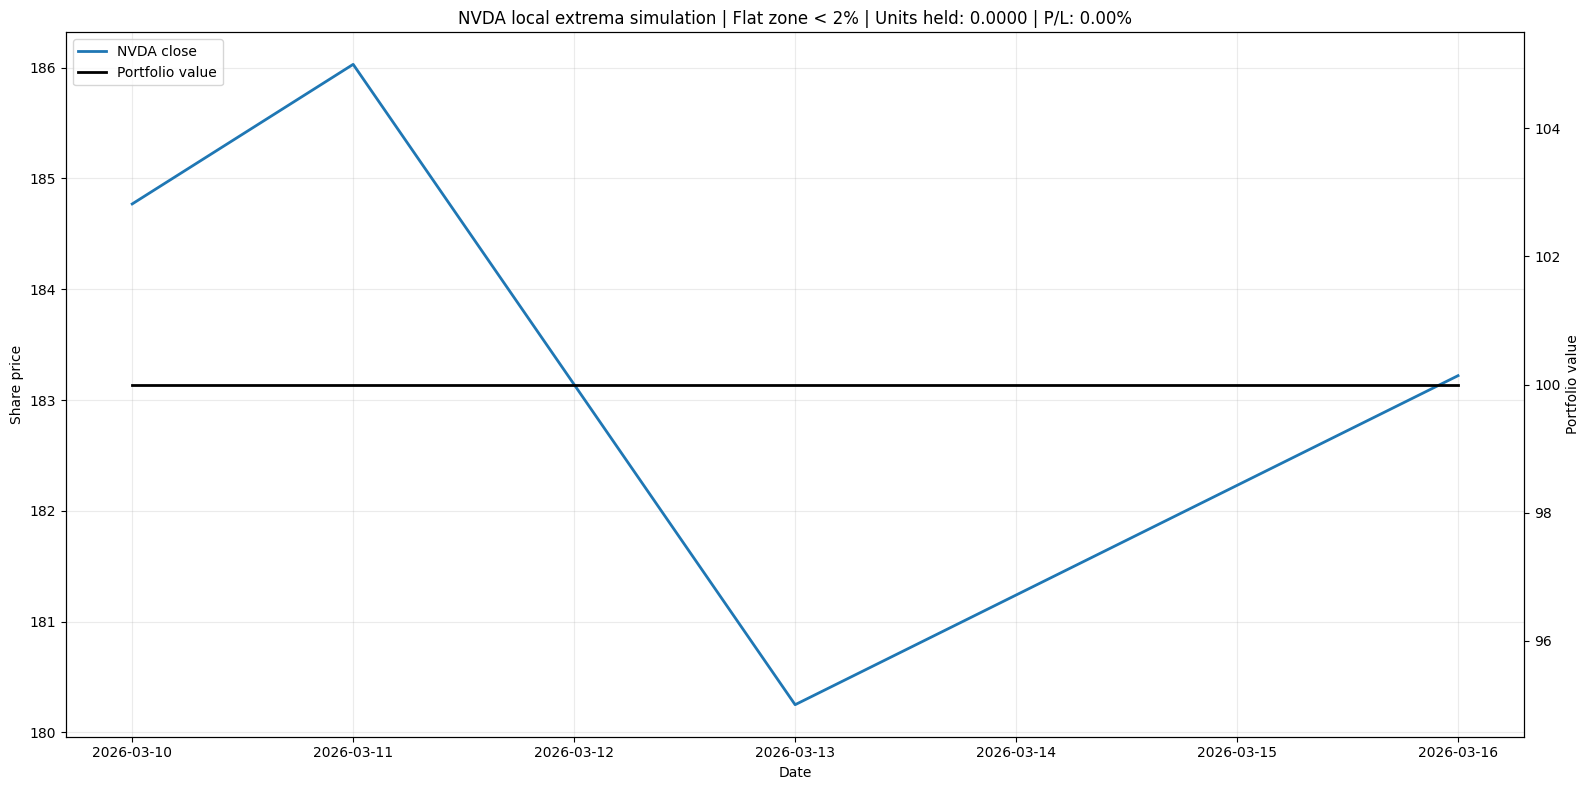

In [26]:
price_history = simulation_result["price_history"].copy()
daily_history = simulation_result["daily_history"].copy()
transactions = simulation_result["transactions"].copy()
simulation_summary = simulation_result["summary"].iloc[0]

buy_txns = transactions[transactions["action"] == "BUY"].copy()
sell_txns = transactions[transactions["action"] == "SELL"].copy()

fig, ax_price = plt.subplots(figsize=(16, 8))
ax_price.plot(
    price_history["Date"],
    price_history["Close"],
    color="#1f77b4",
    linewidth=2,
    label=f"{ticker} close",
)

if not buy_txns.empty:
    ax_price.scatter(
        buy_txns["Date"],
        buy_txns["trade_price"],
        color="#2ca02c",
        marker=".",
        s=90,
        label="Buy trades",
        zorder=5,
    )

if not sell_txns.empty:
    ax_price.scatter(
        sell_txns["Date"],
        sell_txns["trade_price"],
        color="#d62728",
        marker=".",
        s=90,
        label="Sell trades",
        zorder=5,
    )

ax_price.set_xlabel("Date")
ax_price.set_ylabel("Share price")
ax_price.grid(alpha=0.25)

ax_portfolio = ax_price.twinx()
ax_portfolio.plot(
    daily_history["Date"],
    daily_history["portfolio_value"],
    color="#000000",
    linewidth=2,
    label="Portfolio value",
)
ax_portfolio.set_ylabel("Portfolio value")

title = (
    f"{ticker} local extrema simulation | "
    f"Flat zone < {no_change_threshold:.0%} | "
    f"Units held: {simulation_summary['units_held']:.4f} | "
    f"P/L: {simulation_summary['profit_loss_pct']:.2f}%"
)
ax_price.set_title(title)

handles_price, labels_price = ax_price.get_legend_handles_labels()
handles_portfolio, labels_portfolio = ax_portfolio.get_legend_handles_labels()
ax_price.legend(handles_price + handles_portfolio, labels_price + labels_portfolio, loc="upper left")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Block 7: Daily History


In [27]:
simulation_result["daily_history"][[
    "Date",
    "Close",
    "price_change_from_prev_pct",
    "price_change_to_next_pct",
    "signal_text",
    "action",
    "trade_units",
    "trade_value",
    "cash_balance",
    "units_held",
    "holdings_value",
    "portfolio_value",
    "profit_loss_pct",
]]


,Date,Close,price_change_from_prev_pct,price_change_to_next_pct,signal_text,action,trade_units,trade_value,cash_balance,units_held,holdings_value,portfolio_value,profit_loss_pct
0,2026-03-10,184.770004,NaN,0.681926,EDGE,HOLD,0.0,0.0,100.0,0.0,0.0,100.0,0.0
1,2026-03-11,186.029999,0.681926,-1.553513,STATIONARY,HOLD,0.0,0.0,100.0,0.0,0.0,100.0,0.0
2,2026-03-12,183.139999,-1.553513,-1.578027,STATIONARY,HOLD,0.0,0.0,100.0,0.0,0.0,100.0,0.0
3,2026-03-13,180.250000,-1.578027,1.647712,STATIONARY,HOLD,0.0,0.0,100.0,0.0,0.0,100.0,0.0
4,2026-03-16,183.220001,1.647712,NaN,EDGE,HOLD,0.0,0.0,100.0,0.0,0.0,100.0,0.0
